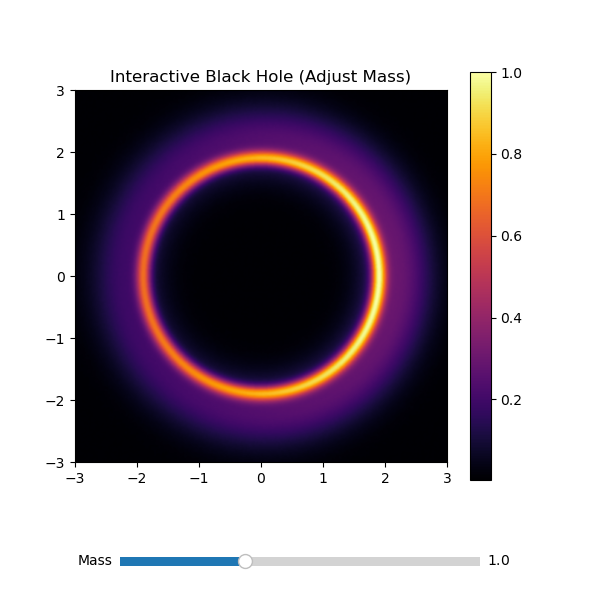

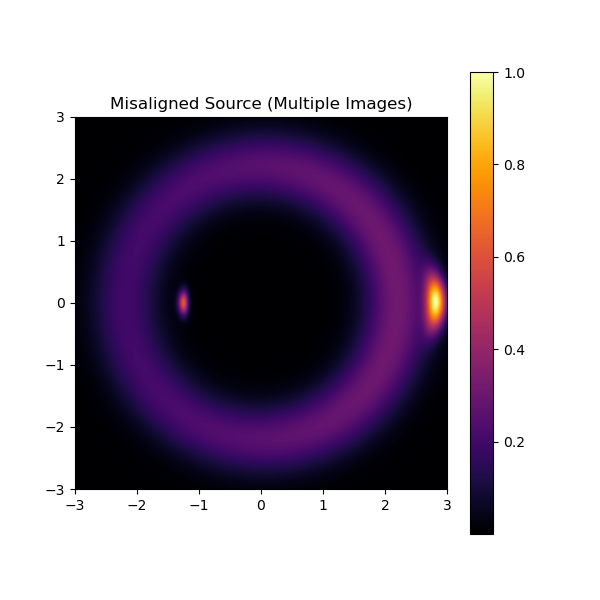

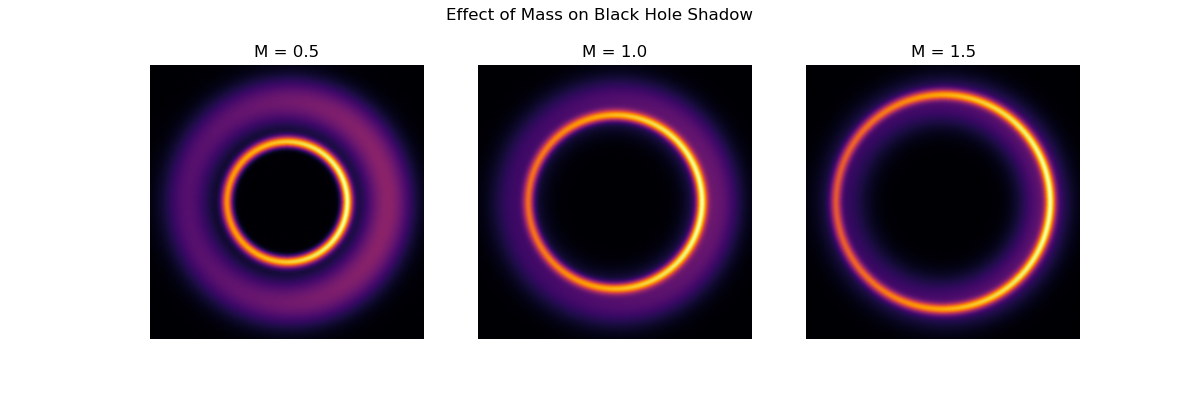

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.widgets import Slider
import os

# Create folder
os.makedirs("Astrophysics_projects/results", exist_ok=True)

# GRID
N = 500   # reduced slightly for smoother slider
x = np.linspace(-3, 3, N)
y = np.linspace(-3, 3, N)
x, y = np.meshgrid(x, y)

r = np.sqrt(x**2 + y**2)
r[r == 0] = 1e-6

# PHYSICS CONSTANTS
G = 1
c = 1

# BACKGROUND SOURCE (aligned → ring)
source = np.exp(-(x**2 + y**2) / 0.05)
source = gaussian_filter(source, sigma=2)

# ACCRETION DISK
disk = np.exp(-((r - 2.2)**2) / 0.3)

# FUNCTION: Compute Image
def compute_image(M_val):
    r_s_val = 2 * G * M_val / c**2
    b_crit_val = 3 * np.sqrt(3) * G * M_val / c**2

    alpha_val = 4 * G * M_val / (c**2 * (r + 0.2))

    x_def = x - alpha_val * (x / r)
    y_def = y - alpha_val * (y / r)

    x_idx_val = ((x_def + 3) / 6 * (N - 1)).astype(int)
    y_idx_val = ((y_def + 3) / 6 * (N - 1)).astype(int)

    x_idx_val = np.clip(x_idx_val, 0, N - 1)
    y_idx_val = np.clip(y_idx_val, 0, N - 1)

    img = source[y_idx_val, x_idx_val]

    inside_val = 1 - (r_s_val / r)
    inside_val[inside_val <= 0] = 1e-6

    b_val = r / np.sqrt(inside_val)
    img[b_val < b_crit_val] = 0

    # Add disk + relativistic boost
    img += 0.35 * disk
    img *= (1 + 0.3 * (x / np.max(x)))

    # Add noise
    noise = 0.02 * np.random.random(img.shape)
    img += noise

    # Smooth + normalize
    img = gaussian_filter(img, sigma=1)
    img = img / np.max(img)

    return img

# INTERACTIVE PLOT
M_init = 1.0
image = compute_image(M_init)

fig, ax = plt.subplots(figsize=(6,6))
plt.subplots_adjust(bottom=0.2)

im = ax.imshow(image, extent=[-3,3,-3,3], origin='lower', cmap='inferno')
ax.set_title("Interactive Black Hole (Adjust Mass)")
plt.colorbar(im, ax=ax)

# Slider axis
ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
mass_slider = Slider(ax_slider, 'Mass', 0.2, 2.5, valinit=M_init)

# Update function
def update(val):
    M_val = mass_slider.val
    new_img = compute_image(M_val)
    im.set_data(new_img)
    fig.canvas.draw_idle()

mass_slider.on_changed(update)
plt.savefig("Astrophysics_projects/results/interactive_blackhole.png", dpi=300)
plt.show()

# MISALIGNED SOURCE CASE
source_misaligned = np.exp(-((x - 1.5)**2 + (y)**2) / 0.05)
source_misaligned = gaussian_filter(source_misaligned, sigma=2)

# reuse last slider mass
M_val = mass_slider.val

r_s_val = 2 * G * M_val / c**2
b_crit_val = 3 * np.sqrt(3) * G * M_val / c**2

alpha_val = 4 * G * M_val / (c**2 * (r + 0.2))

x_def = x - alpha_val * (x / r)
y_def = y - alpha_val * (y / r)

x_idx_val = ((x_def + 3) / 6 * (N - 1)).astype(int)
y_idx_val = ((y_def + 3) / 6 * (N - 1)).astype(int)

x_idx_val = np.clip(x_idx_val, 0, N - 1)
y_idx_val = np.clip(y_idx_val, 0, N - 1)

image_misaligned = source_misaligned[y_idx_val, x_idx_val]

inside_val = 1 - (r_s_val / r)
inside_val[inside_val <= 0] = 1e-6
b_val = r / np.sqrt(inside_val)

image_misaligned[b_val < b_crit_val] = 0

image_misaligned += 0.35 * disk
image_misaligned *= (1 + 0.3 * (x / np.max(x)))

image_misaligned = gaussian_filter(image_misaligned, sigma=1)
image_misaligned = image_misaligned / np.max(image_misaligned)

plt.figure(figsize=(6,6))
plt.imshow(image_misaligned, extent=[-3,3,-3,3], origin='lower', cmap='inferno')
plt.title("Misaligned Source (Multiple Images)")
plt.colorbar()
plt.savefig("Astrophysics_projects/results/misaligned_case.png", dpi=300)
plt.show()

# MASS VARIATION STUDY (STATIC)
masses = [0.5, 1.0, 1.5]
plt.figure(figsize=(12,4))

for i, M_val in enumerate(masses):
    img = compute_image(M_val)

    plt.subplot(1, 3, i+1)
    plt.imshow(img, extent=[-3,3,-3,3], origin='lower', cmap='inferno')
    plt.title(f"M = {M_val}")
    plt.axis('off')

plt.suptitle("Effect of Mass on Black Hole Shadow")
plt.savefig("Astrophysics_projects/results/mass_variation.png", dpi=300)
plt.show()